In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
import matplotlib.pyplot as plt
import tensorflow as tf
# import split_folders
import numpy as np
import cv2
import os
# print(os.listdir("../input"))

In [2]:
real = "fake-face-detection/training_real/"
fake = "fake-face-detection/training_fake/"

real_path = os.listdir(real)
fake_path = os.listdir(fake)

In [3]:
def load_img(path):
    image = cv2.imread(path)
    image = cv2.resize(image, (224, 224))
    return image[...,::-1]

Real Faces


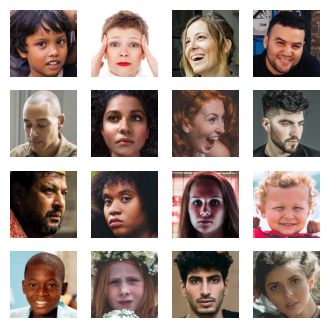

In [4]:
fig = plt.figure(figsize=(4, 4))
print("Real Faces")
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(load_img(real + real_path[i]), cmap='gray')
    # plt.title("real face")
    plt.axis('off')
plt.show()

Fake Face


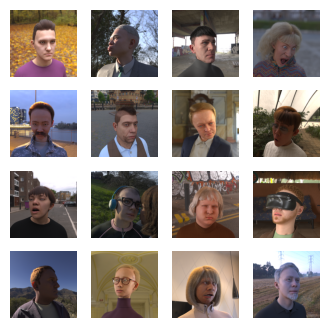

In [5]:
fig = plt.figure(figsize=(4, 4))

print("Fake Face")
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(load_img(fake + fake_path[i]), cmap='gray')
    plt.axis('off')

plt.show()

In [6]:
train_datagen = ImageDataGenerator(horizontal_flip=True,
                                   vertical_flip=False,
                                   rescale=1./255,
                                   validation_split=0.2)

In [7]:
dataset_path = "fake-face-detection"

In [8]:
train = train_datagen.flow_from_directory(dataset_path,
                                          class_mode="binary",
                                          target_size=(96, 96),
                                          batch_size=32,
                                          subset="training")

Found 3142 images belonging to 2 classes.


In [9]:
val = train_datagen.flow_from_directory(dataset_path,
                                          class_mode="binary",
                                          target_size=(96, 96),
                                          batch_size=32,
                                          subset="validation"
                                          )

Found 784 images belonging to 2 classes.


In [10]:
mnet = MobileNetV2(include_top = False, weights = "imagenet" ,input_shape=(96,96,3))

In [11]:
tf.keras.backend.clear_session()

model = Sequential([mnet,
                    GlobalAveragePooling2D(),
                    Dense(512, activation = "relu"),
                    BatchNormalization(),
                    Dropout(0.3),
                    Dense(128, activation = "relu"),
                    Dropout(0.1),
                    # Dense(32, activation = "relu"),
                    # Dropout(0.3),
                    Dense(2, activation = "softmax")])

model.layers[0].trainable = False

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics="accuracy")

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                        

In [12]:
def scheduler(epoch):
    if epoch <= 2:
        return 0.001
    elif epoch > 2 and epoch <= 15:
        return 0.0001 
    else:
        return 0.00001

lr_callbacks = tf.keras.callbacks.LearningRateScheduler(scheduler)

In [13]:
hist = model.fit_generator(train,
                    epochs=5,
                    callbacks=[lr_callbacks],
                    validation_data=val)

C:\Users\JAINAM\AppData\Local\Temp\ipykernel_11444\457645169.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  hist = model.fit_generator(train,


Epoch 1/5
99/99 [==============================] - 86s 837ms/step - loss: 0.2606 - accuracy: 0.8947 - val_loss: 0.1543 - val_accuracy: 0.9388 - lr: 0.0010
Epoch 2/5
99/99 [==============================] - 62s 625ms/step - loss: 0.1560 - accuracy: 0.9351 - val_loss: 0.1983 - val_accuracy: 0.9171 - lr: 0.0010
Epoch 3/5
99/99 [==============================] - 56s 563ms/step - loss: 0.1164 - accuracy: 0.9513 - val_loss: 0.1791 - val_accuracy: 0.9260 - lr: 0.0010
Epoch 4/5
99/99 [==============================] - 50s 507ms/step - loss: 0.0794 - accuracy: 0.9679 - val_loss: 0.1634 - val_accuracy: 0.9298 - lr: 1.0000e-04
Epoch 5/5
99/99 [==============================] - 54s 545ms/step - loss: 0.0744 - accuracy: 0.9717 - val_loss: 0.1351 - val_accuracy: 0.9362 - lr: 1.0000e-04


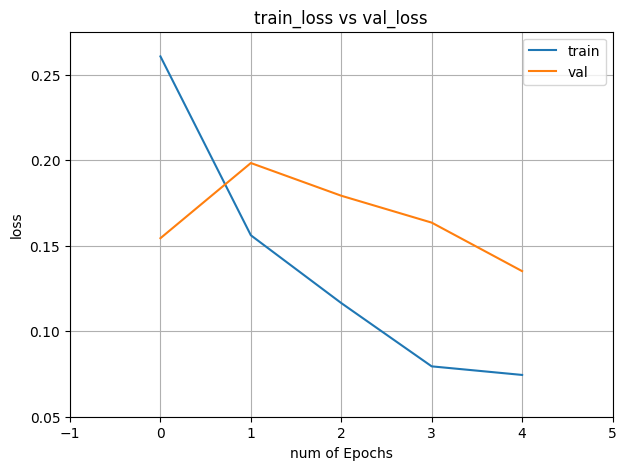

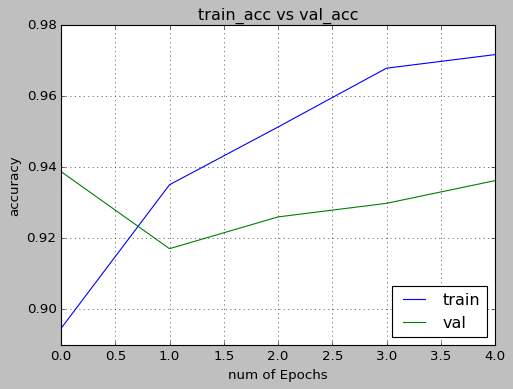

In [14]:
epochs = 5
train_loss = hist.history['loss']
val_loss = hist.history['val_loss']
train_acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
xc = range(epochs)

plt.figure(1,figsize=(7,5))
plt.plot(xc,train_loss)
plt.plot(xc,val_loss)
plt.xlabel('num of Epochs')
plt.ylabel('loss')
plt.title('train_loss vs val_loss')
plt.grid(True)
plt.legend(['train','val'])
#print plt.style.available # use bmh, classic,ggplot for big pictures
plt.style.use(['classic'])

plt.figure(2,figsize=(7,5))
plt.plot(xc,train_acc)
plt.plot(xc,val_acc)
plt.xlabel('num of Epochs')
plt.ylabel('accuracy')
plt.title('train_acc vs val_acc')
plt.grid(True)
plt.legend(['train','val'],loc=4)
#print plt.style.available # use bmh, classic,ggplot for big pictures
plt.style.use(['classic'])

In [15]:
predictions = model.predict_generator(val)

C:\Users\JAINAM\AppData\Local\Temp\ipykernel_11444\902042886.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(val)


In [20]:
predictions

array([[5.2212030e-03, 9.9477875e-01],
       [9.9582255e-01, 4.1774050e-03],
       [2.5484765e-02, 9.7451526e-01],
       ...,
       [4.4748518e-01, 5.5251479e-01],
       [1.3837174e-01, 8.6162829e-01],
       [1.0000000e+00, 2.8560418e-11]], dtype=float32)

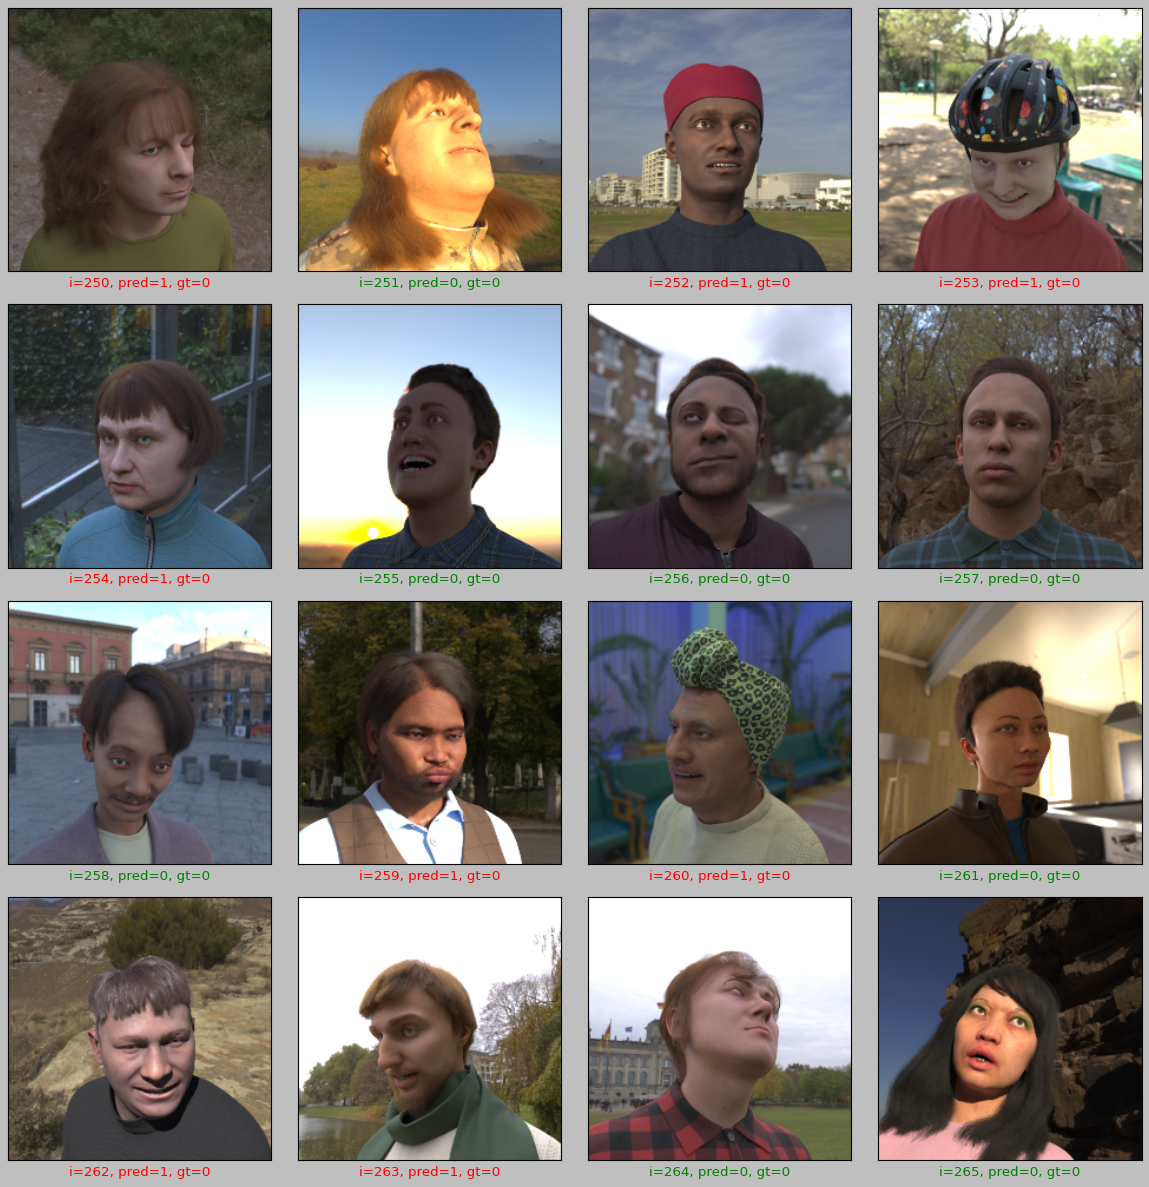

In [16]:
val_path = "fake-face-detection/"
plt.figure(figsize=(15,15))
start_index = 250
for i in range(16):
  plt.subplot(4,4, i+1)
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  preds = np.argmax(predictions[[start_index+i]])
  gt = val.filenames[start_index+i][9:13]
  if gt == "fake":
    gt = 0
  else:
    gt = 1
  if preds != gt:
    col ="r"
  else:
    col = "g"
  plt.xlabel('i={}, pred={}, gt={}'.format(start_index+i,preds,gt),color=col)
  plt.imshow(load_img(val_path+val.filenames[start_index+i]))
  plt.tight_layout()

plt.show()

In [17]:
model_json = model.to_json()
with open('my_model.json', 'w') as json_file:
    json_file.write(model_json)

In [18]:
model.save('model.h5')

In [19]:
model.save_weights('weights.h5')